In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


Mounted at /content/drive


In [ ]:
hour_df = pd.read_csv("/content/drive/MyDrive/hour.csv")
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])


In [ ]:
print(hour_df.columns)


Index(['instant', 'dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
       'casual', 'registered', 'cnt'],
      dtype='object')


In [ ]:
hour_df.isnull().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
hr,0
holiday,0
weekday,0
workingday,0
weathersit,0


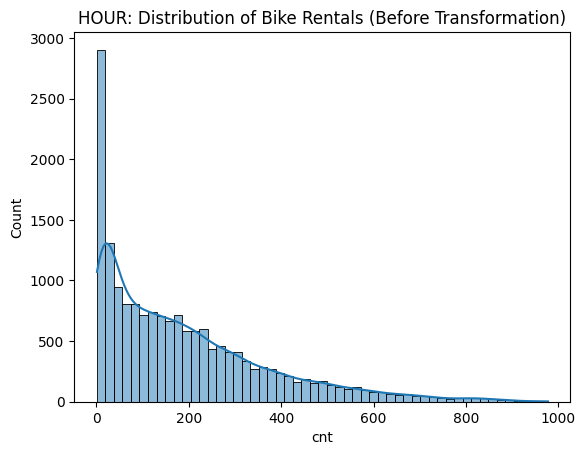

Skewness (Hour): 1.2774116037490577


In [ ]:
sns.histplot(hour_df['cnt'], kde=True)
plt.title("HOUR: Distribution of Bike Rentals (Before Transformation)")
plt.show()

print("Skewness (Hour):", hour_df['cnt'].skew())


In [ ]:
#featuretransformation
hour_df['cnt_sqrt'] = np.sqrt(hour_df['cnt'])


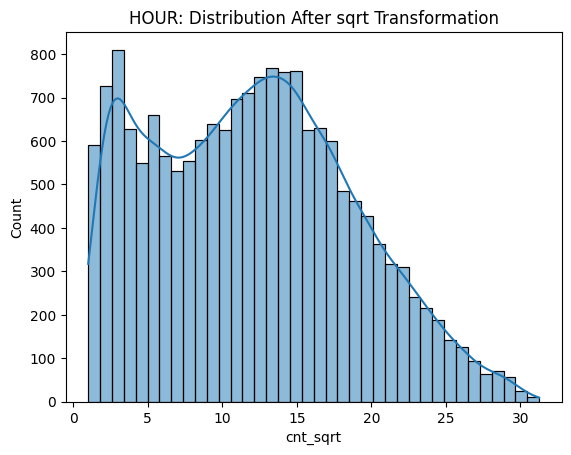

Skewness After (Hour): 0.2864746130055621


In [ ]:
sns.histplot(hour_df['cnt_sqrt'], kde=True)
plt.title("HOUR: Distribution After sqrt Transformation")
plt.show()

print("Skewness After (Hour):", hour_df['cnt_sqrt'].skew())


In [ ]:
#featuregeneration-timebased
hour_df['year'] = hour_df['dteday'].dt.year
hour_df['month'] = hour_df['dteday'].dt.month
hour_df['is_weekend'] = hour_df['weekday'].apply(lambda x: 1 if x in [5,6] else 0)

In [ ]:
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,...,atemp,hum,windspeed,casual,registered,cnt,cnt_sqrt,year,month,is_weekend
0,1,2011-01-01,1,0,1,0,0,6,0,1,...,0.2879,0.81,0.0,3,13,16,4.000000,2011,1,1
1,2,2011-01-01,1,0,1,1,0,6,0,1,...,0.2727,0.80,0.0,8,32,40,6.324555,2011,1,1
2,3,2011-01-01,1,0,1,2,0,6,0,1,...,0.2727,0.80,0.0,5,27,32,5.656854,2011,1,1
3,4,2011-01-01,1,0,1,3,0,6,0,1,...,0.2879,0.75,0.0,3,10,13,3.605551,2011,1,1
4,5,2011-01-01,1,0,1,4,0,6,0,1,...,0.2879,0.75,0.0,0,1,1,1.000000,2011,1,1


In [ ]:
#binning
hour_df['is_peak_hour'] = hour_df['hr'].apply(
    lambda x: 1 if x in [7,8,17,18] else 0
)


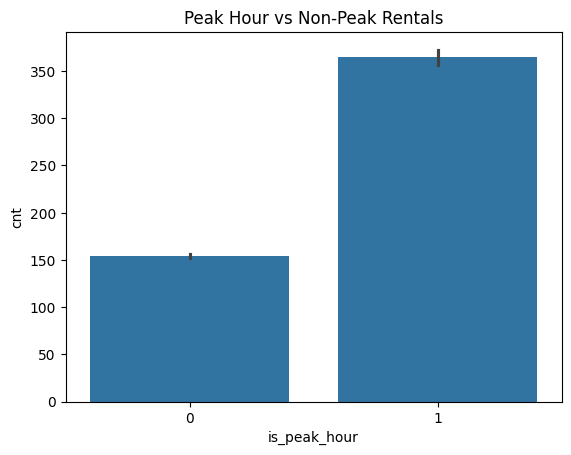

In [ ]:
sns.barplot(x='is_peak_hour', y='cnt', data=hour_df)
plt.title("Peak Hour vs Non-Peak Rentals")
plt.show()


In [ ]:
#featureinteraction
hour_df['weather_index'] = hour_df['temp'] + hour_df['hum'] + hour_df['windspeed']
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,...,windspeed,casual,registered,cnt,cnt_sqrt,year,month,is_weekend,is_peak_hour,weather_index
0,1,2011-01-01,1,0,1,0,0,6,0,1,...,0.0,3,13,16,4.000000,2011,1,1,0,1.05
1,2,2011-01-01,1,0,1,1,0,6,0,1,...,0.0,8,32,40,6.324555,2011,1,1,0,1.02
2,3,2011-01-01,1,0,1,2,0,6,0,1,...,0.0,5,27,32,5.656854,2011,1,1,0,1.02
3,4,2011-01-01,1,0,1,3,0,6,0,1,...,0.0,3,10,13,3.605551,2011,1,1,0,0.99
4,5,2011-01-01,1,0,1,4,0,6,0,1,...,0.0,0,1,1,1.000000,2011,1,1,0,0.99


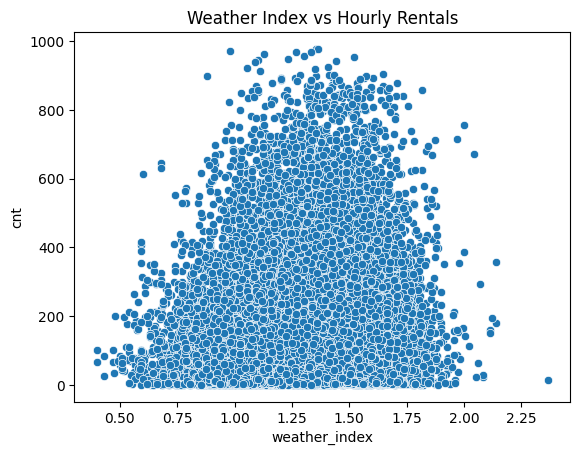

In [ ]:
sns.scatterplot(x='weather_index', y='cnt', data=hour_df)
plt.title("Weather Index vs Hourly Rentals")
plt.show()



In [ ]:
y_hour = hour_df['cnt']


In [ ]:
X_hour = hour_df.drop(columns=[
    'cnt',
    'dteday'
])


In [ ]:
cat_cols_hour = ['season', 'weathersit', 'weekday']


In [ ]:
#one-hotencoding
X_hour = pd.get_dummies(
    X_hour,
    columns=cat_cols_hour,
    drop_first=True
)


In [ ]:
X_hour.shape, y_hour.shape


((17379, 30), (17379,))

In [ ]:
X_hour.head()

,instant,yr,mnth,hr,holiday,workingday,temp,atemp,hum,windspeed,...,season_4,weathersit_2,weathersit_3,weathersit_4,weekday_1,weekday_2,weekday_3,weekday_4,weekday_5,weekday_6
0,1,0,1,0,0,0,0.24,0.2879,0.81,0.0,...,False,False,False,False,False,False,False,False,False,True
1,2,0,1,1,0,0,0.22,0.2727,0.80,0.0,...,False,False,False,False,False,False,False,False,False,True
2,3,0,1,2,0,0,0.22,0.2727,0.80,0.0,...,False,False,False,False,False,False,False,False,False,True
3,4,0,1,3,0,0,0.24,0.2879,0.75,0.0,...,False,False,False,False,False,False,False,False,False,True
4,5,0,1,4,0,0,0.24,0.2879,0.75,0.0,...,False,False,False,False,False,False,False,False,False,True


In [ ]:
y_hour.head()

,cnt
0,16
1,40
2,32
3,13
4,1
